# Load Data

In [55]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, ttest_rel
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
from scipy.stats import pearsonr
from scipy.stats import pointbiserialr
from scipy.stats import trim_mean
from scipy.stats.mstats import winsorize
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Probit, Logit
from stargazer.stargazer import Stargazer
from statsmodels.stats.power import TTestIndPower
import datetime
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)

In [22]:
dg = pd.read_excel('../../processed_data/04_delegator/delegator_cleaned.xlsx')

dg.female = dg.female.astype('category')
dg.went_to_uni = dg.went_to_uni.astype('category')
dg.leader = dg.leader.astype('category')

In [23]:
dg.time_taken.describe()

count     159.000000
mean      746.553459
std       392.844103
min       267.000000
25%       559.500000
50%       697.000000
75%       838.500000
max      4563.000000
Name: time_taken, dtype: float64

Baseline: Punish - 0; Treatment: No Punish - 1

# Create Helper Functions and Variables

In [24]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

# Balance across observables

In [25]:
# Define variables
variables = ['age', 'female', 'socio_status', 'went_to_uni', 'technology_score', 'leader']
treatment_groups = [0, 1]
summary_table = []

for var in variables:
    if dg[var].dtype == 'float64' or dg[var].dtype == 'int64':  # Continuous variable
        # Means by treatment group
        means = [dg[dg['treat'] == treatment][var].mean() for treatment in treatment_groups]
        
        # Perform ANOVA
        groups = [dg[dg['treat'] == treatment][var].dropna() for treatment in treatment_groups]
        t_stat, p_val = ttest_ind(*groups)
        
        # Append to summary with mean values per treatment
        summary_table.append({
            'Variable': var,
            **{f'Mean (Treatment {t})': means[i] for i, t in enumerate(treatment_groups)},
            'p-value': p_val
        })
        
    else:  # Categorical variable
        print(var)
        # Contingency table for chi-square test
        contingency_table = pd.crosstab(dg['treat'], dg[var])
        chi2, p_val, _, _ = chi2_contingency(contingency_table)
        
        # Means as proportions for each treatment
        means = contingency_table.div(contingency_table.sum(axis=1), axis=0)[1]
        
        # Append to summary with mean values per treatment
        summary_table.append({
            'Variable': var,
            **{f'Mean (Treatment {t})': means[t] for t in treatment_groups},
            'p-value': p_val
        })

# Convert summary to DataFrame
summary_df = pd.DataFrame(summary_table)

summary_df.columns = ['Variable', 'Baseline (punishment)', 'Treatment (no punishment)', 'p-value']
summary_df['Variable'] = summary_df['Variable'].replace({'age': 'Age', 'female': 'Female', 'socio_status': 'Socio-economic status', 'went_to_uni': 'Went to uni', 'technology_score': 'Technology score', 'leader': 'Leadership position'})
summary_df = summary_df.round({'Baseline (punishment)': 3, 'Treatment (no punishment)': 3, 'p-value': 3})

print(summary_df.to_latex(index=False))


female
went_to_uni
leader
\begin{tabular}{lrrr}
\toprule
             Variable &  Baseline (punishment) &  Treatment (no punishment) &  p-value \\
\midrule
                  Age &                 39.026 &                     37.877 &    0.552 \\
               Female &                  0.487 &                      0.494 &    1.000 \\
Socio-economic status &                  5.179 &                      5.321 &    0.564 \\
          Went to uni &                  0.575 &                      0.556 &    0.928 \\
     Technology score &                  2.088 &                      2.284 &    0.323 \\
  Leadership position &                  0.362 &                      0.333 &    0.824 \\
\bottomrule
\end{tabular}



C:\Users\Felix\AppData\Local\Temp\ipykernel_876\236497858.py:45: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  print(summary_df.to_latex(index=False))


In [26]:
dg.technology_score.describe()

count    161.000000
mean       2.186335
std        1.256010
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: technology_score, dtype: float64

# Attention Checks

In [27]:
dg['pass_att1'].value_counts()

0    105
1     56
Name: pass_att1, dtype: int64

In [28]:
dg['pass_att2'].value_counts()

1    131
0     30
Name: pass_att2, dtype: int64

In [29]:
dg['error_confidence'].value_counts()

0    139
1     21
4      1
Name: error_confidence, dtype: int64

In [30]:
dg['error_difficulty'].value_counts()

0    160
1      1
Name: error_difficulty, dtype: int64

In [31]:
dg[(dg['pass_att1']==1) & (dg['pass_att2']==1) & (dg['error_confidence']==0) & (dg['error_difficulty']==0)].shape

(42, 136)

In [32]:
#correlation between time it takes to complete and likelihood of passing attention checks?
dg[['time_taken', 'pass_att1', 'pass_att2', 'punish_bel_time']].corr()

,time_taken,pass_att1,pass_att2,punish_bel_time
time_taken,1.000000,0.126700,-0.001121,0.409954
pass_att1,0.126700,1.000000,0.048054,0.048671
pass_att2,-0.001121,0.048054,1.000000,0.038222
punish_bel_time,0.409954,0.048671,0.038222,1.000000


In [33]:
#attention check pass rates by treatment
dg[['treat', 'pass_att1', 'pass_att2']].groupby('treat').mean()

,pass_att1,pass_att2
treat,,
0,0.350000,0.762500
1,0.345679,0.864198


# Task Performance

Let's check subjects' performance in the task. How much does it vary from image to image, between treatment?

Perhaps it is for some reason nice to show that both groups perform similarly, so that delegators are on average in the same emotional state when making a decision, and that when we link performance to delegation decision, a critic could say that differences in delegation between treatments come from differences in performance, which I could then alleviate. Even more importantly, beliefs about performance should actually be equal rather than actual performance.

## Overall performance

In [34]:
print(dg[['overall_score']].value_counts().sort_index())
dg['overall_score'].describe()

overall_score
0                 3
1                20
2                42
3                40
4                37
5                15
6                 4
dtype: int64


count    161.000000
mean       2.925466
std        1.325485
min        0.000000
25%        2.000000
50%        3.000000
75%        4.000000
max        6.000000
Name: overall_score, dtype: float64

In [35]:
#show performance of two treatments
print(dg.groupby('treat')['overall_score'].value_counts().sort_index())
print(dg.groupby('treat').agg({'overall_score': 'mean'}))
print(ttest_ind(dg[dg.treat==0]['overall_score'], dg[dg.treat==1]['overall_score']))

treat  overall_score
0      0                 2
       1                15
       2                16
       3                22
       4                18
       5                 6
       6                 1
1      0                 1
       1                 5
       2                26
       3                18
       4                19
       5                 9
       6                 3
Name: overall_score, dtype: int64
       overall_score
treat               
0            2.76250
1            3.08642
Ttest_indResult(statistic=-1.5572658418424168, pvalue=0.12139559925442335)


Performance is not different between treatments, which means that differences in delegation would not be driven by differences in performance, even if own performance would determine delegation. A test on beliefs about performance will follow.

## Performance By Task

In [15]:
#performance by task
for i in range(10):
    if i == 0:
        p_by_task = pd.DataFrame(dg['success_r' + str(i+1)].describe())
    else:
        p_by_task['success_r' + str(i+1)] = dg['success_r' + str(i+1)].describe()

p_by_task['success_last'] = dg['success_last'].describe()
p_by_task

,success_r1,success_r2,success_r3,success_r4,success_r5,success_r6,success_r7,success_r8,success_r9,success_r10,success_last
count,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,161.000000,79.000000
mean,0.397516,0.124224,0.397516,0.484472,0.447205,0.335404,0.149068,0.105590,0.086957,0.397516,0.316456
std,0.490911,0.330866,0.490911,0.501318,0.498756,0.473605,0.357267,0.308271,0.282650,0.490911,0.468065
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [16]:
print(dg[['treat', 'success_last']].groupby('treat').describe())
print(ttest_ind(dg[(dg.treat==0) & (dg.success_last.isna()==False)]['success_last'], dg[(dg.treat==1) & (dg.success_last.isna()==False)]['success_last']))

      success_last                                             
             count      mean       std  min  25%  50%  75%  max
treat                                                          
0             46.0  0.217391  0.417029  0.0  0.0  0.0  0.0  1.0
1             33.0  0.454545  0.505650  0.0  0.0  0.0  1.0  1.0
Ttest_indResult(statistic=-2.279980753490459, pvalue=0.02537692490892508)


People perform much better in the extra task if no punishment is possible. Is this because the people that decide to delegate are just better at predicting? I could compare to the performance in the first 10 tasks and it turns out that they slightly outperform also in the first ten tasks, but not to the same extent.

In [43]:
#full sample
print(dg[(dg.treat==0) & (dg.delegation==0)]['overall_score'].mean())
print(dg[(dg.treat==1) & (dg.delegation==0)]['overall_score'].mean())

2.9782608695652173
3.121212121212121


## Performance (absolute error)

In [37]:
print(dg[['treat', 'true_performance']].groupby('treat').describe()) #seems to be influenced by outlier

      true_performance                                                     \
                 count       mean        std   min     25%    50%     75%   
treat                                                                       
0                 80.0  23.310000   5.765186  12.5  19.075  21.95  26.425   
1                 81.0  26.404938  22.127561  13.8  19.900  22.40  24.600   

              
         max  
treat         
0       48.1  
1      169.4  


## Confidence, Difficulty, Overconfidence

There may be a rational for using the category that they assigned the most probability to, because of the incentive-compatibility issues of the elicitation procedure.

In [103]:
dg[['overall_score', 'wa_confidence', 'highest_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others']].describe().round(3)

,overall_score,wa_confidence,highest_confidence,overconfidence,wa_difficulty,overconfidence_to_others
count,161.000,161.000,161.000,161.000,161.000,161.000
mean,2.925,4.763,4.448,1.837,4.744,0.018
std,1.325,1.889,2.912,2.155,1.488,1.289
min,0.000,0.100,0.000,-5.290,0.150,-5.850
25%,2.000,3.700,2.000,0.250,4.170,-0.530
50%,3.000,4.860,5.000,2.010,4.860,0.000
75%,4.000,5.750,6.000,3.200,5.450,0.690
max,6.000,9.450,10.000,7.000,9.090,2.960


## Treatment comparisons

### Descriptives

In [148]:
dg.overall_score.median()

3.0

In [104]:
dg[['treat', 'overall_score', 'wa_confidence', 'highest_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others']].groupby('treat').mean()

,overall_score,wa_confidence,highest_confidence,overconfidence,wa_difficulty,overconfidence_to_others
treat,,,,,,
0,2.76250,4.653000,4.252083,1.890500,4.615375,0.037625
1,3.08642,4.870864,4.642416,1.784444,4.871605,-0.000741


### Tests

In [149]:
for i in ['overall_score', 'wa_confidence', 'highest_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others']:
    print(i)
    print(ttest_ind(dg[dg['treat']==0][i], dg[dg['treat']==1][i]))

overall_score
Ttest_indResult(statistic=-1.5572658418424168, pvalue=0.12139559925442335)
wa_confidence
Ttest_indResult(statistic=-0.7305585710213202, pvalue=0.46612393102036753)
highest_confidence
Ttest_indResult(statistic=-0.8497942750623872, pvalue=0.39671723453520713)
overconfidence
Ttest_indResult(statistic=0.31128006992771673, pvalue=0.755995461655527)
wa_difficulty
Ttest_indResult(statistic=-1.0932205641603983, pvalue=0.2759505016789033)
overconfidence_to_others
Ttest_indResult(statistic=0.18821523140593618, pvalue=0.850947932796235)


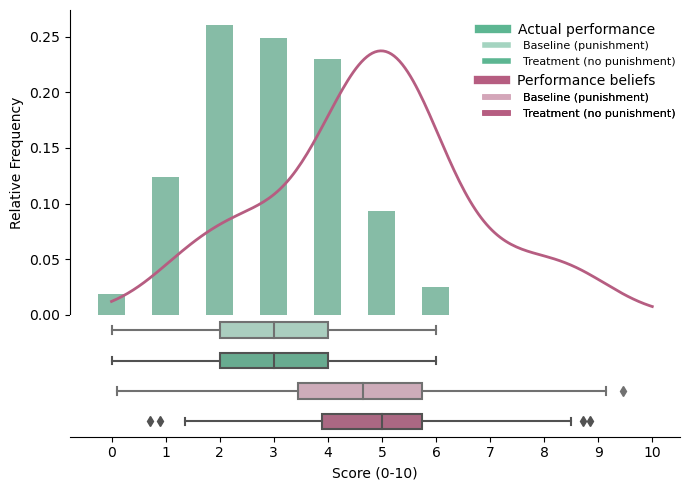

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Set up the figure for overall performance
fig, ax = plt.subplots(5, 1, figsize=(7, 5), sharex=True, gridspec_kw={'height_ratios': [10, 1, 1, 1, 1], 'hspace': 0})

# Define colors
colors = ['#5DB692', '#B65D81']
#colors = ['#C4A54F', '#4F6EC4']
bar_color = colors[0]
boxplot_color_0 = sns.light_palette(bar_color, n_colors=3)[1]
boxplot_color_1 = sns.light_palette(bar_color, n_colors=3)[2]
density_color = colors[1]
boxplot_conf_color_0 = sns.light_palette(density_color, n_colors=3)[1]
boxplot_conf_color_1 = sns.light_palette(density_color, n_colors=3)[2]

# Plotting the bar chart for actual performance scores
score_counts = dg['overall_score'].value_counts(normalize=True).sort_index()
sns.barplot(x=score_counts.index, y=score_counts.values, color=bar_color, alpha=0.8, ax=ax[0], width=0.5)

# Adding density plot for expectations from 0 to 10
sns.kdeplot(dg['wa_confidence'], color=density_color, linewidth=2, ax=ax[0], clip=(0, 10))

ax[0].set_ylabel('Relative Frequency')
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
ax[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Plotting the horizontal boxplots for actual performance and expectations by treatment
sns.boxplot(x=dg[dg.treat == 0]['overall_score'], ax=ax[1], color=boxplot_color_0, width=0.5)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].spines['bottom'].set_visible(False)
ax[1].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax[1].tick_params(axis='y', which='both', left=False, labelleft=False)

sns.boxplot(x=dg[dg.treat == 1]['overall_score'], ax=ax[2], color=boxplot_color_1, width=0.5)
ax[2].spines['top'].set_visible(False)
ax[2].spines['right'].set_visible(False)
ax[2].spines['left'].set_visible(False)
ax[2].spines['bottom'].set_visible(False)
ax[2].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax[2].tick_params(axis='y', which='both', left=False, labelleft=False)

sns.boxplot(x=dg[dg.treat == 0]['wa_confidence'], ax=ax[3], color=boxplot_conf_color_0, width=0.5)
ax[3].spines['top'].set_visible(False)
ax[3].spines['right'].set_visible(False)
ax[3].spines['left'].set_visible(False)
ax[3].spines['bottom'].set_visible(False)
ax[3].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax[3].tick_params(axis='y', which='both', left=False, labelleft=False)

sns.boxplot(x=dg[dg.treat == 1]['wa_confidence'], ax=ax[4], color=boxplot_conf_color_1, width=0.5)
ax[4].spines['top'].set_visible(False)
ax[4].spines['right'].set_visible(False)
ax[4].spines['left'].set_visible(False)
ax[4].tick_params(axis='y', which='both', left=False, labelleft=False)

ax[4].set_xlabel('Score (0-10)')
ax[4].set_xticks(range(11))
ax[4].set_xticklabels(range(11))

f1 = plt.Line2D([0], [0], color=bar_color, lw=6, label='Actual performance')
f2 = plt.Line2D([0], [0], color=boxplot_color_0, lw=4, linestyle='-', label='Baseline')
f3 = plt.Line2D([0], [0], color=boxplot_color_1, lw=4, linestyle='-', label='No Punishment')
f4 = plt.Line2D([0], [0], color=density_color, lw=6, label='Performance beliefs')
f5 = plt.Line2D([0], [0], color=boxplot_conf_color_0, lw=4, linestyle='-', label='Baseline')
f6 = plt.Line2D([0], [0], color=boxplot_conf_color_1, lw=4, linestyle='-', label='No Punishment')

# Adding the main and sub legends
legend1 = ax[0].legend([f1], ['Actual performance'], fontsize=10, loc='upper right', bbox_to_anchor=(0.98, 1), frameon=False)
legend2 = ax[0].legend([f2, f3], ['  Baseline (punishment)', '  Treatment (no punishment)'], fontsize=8, loc='upper right', bbox_to_anchor=(1.01, 0.93), frameon=False)
legend3 = ax[0].legend([f4], ['Performance beliefs'], fontsize=10, loc='upper right', bbox_to_anchor=(0.98, 0.83), frameon=False)
legend4 = ax[0].legend([f5, f6], ['  Baseline (punishment)', '  Treatment (no punishment)'], fontsize=8, loc='upper right', bbox_to_anchor=(1.01, 0.76), frameon=False)
ax[0].add_artist(legend1)
ax[0].add_artist(legend2)
ax[0].add_artist(legend3)
ax[0].add_artist(legend4)

plt.tight_layout()

plt.savefig("../../output/performance.png", bbox_inches='tight')
plt.show()

In [107]:

dg[dg['confidence8']==100]

,code,overall_score,session_code,test_slider,guess_r1,truth_r1,success_r1,guess_r2,truth_r2,success_r2,guess_r3,truth_r3,success_r3,guess_r4,truth_r4,success_r4,guess_r5,truth_r5,success_r5,guess_r6,truth_r6,success_r6,guess_r7,truth_r7,success_r7,guess_r8,truth_r8,success_r8,guess_r9,truth_r9,success_r9,guess_r10,truth_r10,success_r10,confidence0,confidence1,confidence2,confidence3,confidence4,confidence5,confidence6,confidence7,confidence8,confidence9,confidence10,error_confidence,difficulty0,difficulty1,difficulty2,difficulty3,difficulty4,difficulty5,difficulty6,difficulty7,difficulty8,difficulty9,difficulty10,error_difficulty,random_order_del,delegation,guess_last,truth_last,success_last,confidence_last,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad,switching_point,del_reason,research_about,unclear,attention,time_taken,total_approvals,ethnicity,gender,abroad,languages,tech_at_work,employ_sector,leadership,management_exp,education,body_weight,religion,dating_apps,hobbies,device_usage,internet_products,programming,socio_status,nft,crypto,income,age,sex,ethnicity_simple,country_birth,nationality,language,student_status,employ_status,delegation_hypo,explain_punish_bad,explain_punish_good,pilot,treat,female,pass_att1,pass_att2,wa_confidence,highest_confidence,overconfidence,wa_difficulty,overconfidence_to_others,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad,nodel_del_good_x_treat,nodel_del_bad_x_treat,punish_bel_time,technology_score,religious,went_to_uni,leader,tech_use_at_work_often,white,treat_x_overall_score,true_performance,overall_score_x_treat
145,mj2d99wr,1,u68gz72j,168,178,181,1,184,216,0,120,150,0,114,128,0,150,161,0,164,190,0,164,196,0,140,113,0,155,190,0,155,169,0,0,0,0,0,0,0,0,0,100,0,0,0,0,0,0,0,0,0,0,100,0,0,0,0,0,0,154.0,150.0,1.0,80.0,0.0,0.0,0.0,0.0,100,I thought that my choice would seem a better o...,NaN,NaN,0.5,714.0,255.0,White/Caucasian,NaN,No,English,more than once a day,Other,Yes,Yes,Undergraduate degree (BA/BSc/other),Slightly Overweight,"Non Religious (e.g. Agnostic, Atheist, No Reli...",No,"Science, Health & Fitness, Travelling",Multiple times every day,"Smart TV (e.g. Samsung, LG, JVC), Games consol...",Yes,5.0,I don’t know what an NFT is,Yes,"£20,000 - £29,999",48.0,Male,White,United Kingdom,United Kingdom,English,No,Full-Time,0.0,NaN,NaN,0,1,0.0,0,1,8.0,8.0,7.0,7.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,32,3,0,1,1,1,1,1,224,1


In [108]:
dg.groupby('treat')['overall_score'].describe()

,count,mean,std,min,25%,50%,75%,max
treat,,,,,,,,
0,80.0,2.76250,1.333538,0.0,2.0,3.0,4.0,6.0
1,81.0,3.08642,1.305733,0.0,2.0,3.0,4.0,6.0


# Delegation

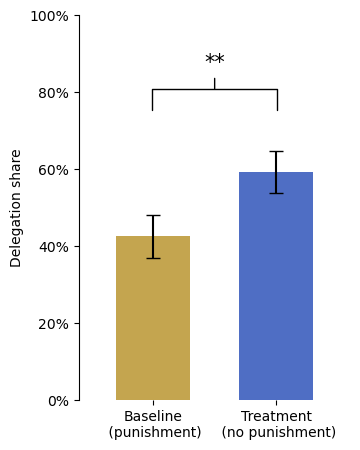

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

plt.figure(figsize=(3.5, 5))

# Calculate mean and SEM for each treatment group
group_stats = dg.groupby('treat')['delegation'].agg(['mean', 'sem']).reset_index()

# X positions for the bars
x_positions = [1, 1.05]

# Define custom pastel colors
colors = ['#C4A54F', '#4F6EC4'] # You can choose any hex color codes

# Plot the bars with custom colors
plt.bar(x_positions, group_stats['mean'], yerr=group_stats['sem'], capsize=5, width=0.03, color=colors)

# Add annotation
fs = 10
plt.annotate('**', xy=(0.5, 0.8), xytext=(0.5, 0.85), xycoords='axes fraction', 
             fontsize=fs * 1.5, ha='center', va='bottom',
             arrowprops=dict(arrowstyle='-[, widthB=3, lengthB=1', lw=1.0, color='k'))

# Labels and limits

plt.ylabel('Delegation share')
plt.ylim(0, 1)
plt.xlim(0.97, 1.08)
plt.xticks(x_positions, ['Baseline\n (punishment)', 'Treatment\n (no punishment)'])

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

ax.yaxis.set_major_formatter(PercentFormatter(1.0))

plt.savefig("../../output/delegation_shares.png", bbox_inches="tight")

# Display the plot
plt.show()


In [110]:
import pandas as pd
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportions_ztest


# Create a contingency table
contingency_table = pd.crosstab(dg['treat'], dg['delegation'])
print("Contingency Table:")
print(contingency_table)

# Perform the Chi-Squared test
chi2_stat, p_val_chi2, dof, expected = chi2_contingency(contingency_table)
print("\nChi-Squared Test Results:")
print(f"Chi-Squared Statistic: {chi2_stat}")
print(f"p-value: {p_val_chi2}")
print(f"Degrees of Freedom: {dof}")
print("Expected Frequencies:")
print(expected)

# Perform Fisher's Exact Test if applicable
if contingency_table.shape == (2, 2):
    contingency_array = contingency_table.to_numpy()
    odds_ratio, p_val_fisher = fisher_exact(contingency_array)
    print("\nFisher's Exact Test Results:")
    print(f"Odds Ratio: {odds_ratio}")
    print(f"p-value: {p_val_fisher}")
else:
    print("\nFisher's Exact Test is only applicable for 2x2 tables.")

# Prepare data for the Two-Proportion Z-Test
delegation_counts = dg.groupby('treat')['delegation'].agg(['sum', 'count'])

# Extract successes and observations
successes = delegation_counts['sum'].values
nobs = delegation_counts['count'].values

# Perform the two-proportion z-test
z_stat, p_val_ztest = proportions_ztest(count=successes, nobs=nobs)
print("\nTwo-Proportion Z-Test Results:")
print(f"Z-Statistic: {z_stat}")
print(f"p-value: {p_val_ztest}")


Contingency Table:
delegation   0   1
treat             
0           46  34
1           33  48

Chi-Squared Test Results:
Chi-Squared Statistic: 3.877698836565549
p-value: 0.04893158048933514
Degrees of Freedom: 1
Expected Frequencies:
[[39.25465839 40.74534161]
 [39.74534161 41.25465839]]

Fisher's Exact Test Results:
Odds Ratio: 1.967914438502674
p-value: 0.040733639443774707

Two-Proportion Z-Test Results:
Z-Statistic: -2.1268398476711714
p-value: 0.03343339218516425


In [46]:
print(dg.groupby(['treat']).agg({'delegation': 'mean', 'delegation_hypo': 'mean'}))
ttest_rel(dg[dg['treat']==1]['delegation'], dg[dg['treat']==1]['delegation_hypo'])

       delegation  delegation_hypo
treat                             
0        0.425000              NaN
1        0.592593         0.506173


TtestResult(statistic=1.7180824278583557, pvalue=0.08964990629826414, df=80)

## What drives delegation?

## More effort in extra task?

In [ ]:
dg.groupby(['treat', 'delegation'])['overall_score', 'success_last', 'truth_last', 'guess_last'].mean()

C:\Users\Felix\AppData\Local\Temp\ipykernel_876\139117756.py:1: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  dg.groupby(['treat', 'delegation'])['overall_score', 'success_last', 'truth_last', 'guess_last', 'true_performance'].mean()


overall_score  success_last  truth_last  guess_last  \
treat delegation                                                        
0     0                2.978261      0.217391       150.0  171.043478   
      1                2.470588           NaN         NaN         NaN   
1     0                3.121212      0.454545       150.0  159.606061   
      1                3.062500           NaN         NaN         NaN   

                  true_performance  
treat delegation                    
0     0                  22.465217  
      1                  24.452941  
1     0                  30.848485  
      1                  23.350000

In [113]:
contingency_table = pd.crosstab(dg['treat'], dg['success_last'])

print(contingency_table)
print(chi2_contingency(contingency_table))

dg['dev_last'] = dg['guess_last']-dg['truth_last']

print(ttest_ind(dg[dg['treat']==0]['dev_last'], dg[dg['treat']==1]['dev_last'], nan_policy="omit"))

success_last  0.0  1.0
treat                 
0              36   10
1              18   15
Chi2ContingencyResult(statistic=3.959839823354314, pvalue=0.046598137214798906, dof=1, expected_freq=array([[31.44303797, 14.55696203],
       [22.55696203, 10.44303797]]))
Ttest_indResult(statistic=2.1294839022228613, pvalue=0.036409706991469906)


In [114]:
#controlling for performance in the first ten tasks, because it is about an increase in effort
dg['performance_increase'] = dg.true_performance/10 - abs(dg.dev_last)

dg[['performance_increase', 'true_performance', 'truth_last', 'guess_last']]

print(dg.groupby('treat')['performance_increase'].mean())
print(ttest_ind(dg[dg['treat']==0]['performance_increase'], dg[dg['treat']==1]['performance_increase'], nan_policy="omit"))



treat
0     0.508696
1    10.939394
Name: performance_increase, dtype: float64
Ttest_indResult(statistic=-2.752810246651569, pvalue=0.007366121365030604)


In [115]:
dg.groupby(['treat', 'delegation'])['overall_score'].mean()

treat  delegation
0      0             2.978261
       1             2.470588
1      0             3.121212
       1             3.062500
Name: overall_score, dtype: float64

### Looking at Baseline and 'No punishment' together.

In [116]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit, probit
from statsmodels.iolib.summary2 import summary_col
import numpy as np

#dg[(dg['pass_att2']==1)] 
data = dg.copy()

# Define socio-demographic variables (replace with your actual variables)
#'technology_score', 'religious', 'went_to_uni', 'leader', 'tech_use_at_work_often', 'white', 'age', 'female', 'socio_status'
socio_demographics = ['technology_score', 'went_to_uni', 'leader', 'tech_use_at_work_often', 'age', 'female', 'socio_status']  # Replace with your variables

# Concatenate socio-demographic variables into a string
socio_demographics_str = ' + '.join(socio_demographics)

# List of regression formulas
model_formulas = [
    'delegation ~ treat',
    'delegation ~ treat + overall_score',
    'delegation ~ treat + true_performance',
    'delegation ~ treat + wa_confidence',
    'delegation ~ treat + overconfidence_to_others',
    'delegation ~ treat + wa_difficulty',
    'delegation ~ treat + switching_point',
    f'delegation ~ treat + {socio_demographics_str}',
]

# Lists to store model results
lpm_results = []
logit_results = []
probit_results = []

for formula in model_formulas:
    # Linear Probability Model (OLS)
    lpm = ols(formula=formula, data=data).fit(cov_type='HC3')
    lpm_results.append(lpm)
    
    # Logit Model
    logit_model = logit(formula=formula, data=data).fit(cov_type='HC3', disp=False)
    logit_results.append(logit_model)
    
    # Probit Model
    probit_model = probit(formula=formula, data=data).fit(cov_type='HC3', disp=False)
    probit_results.append(probit_model)

# Combine all models into one list
all_models = lpm_results + logit_results + probit_results

# Create model names
model_names = []
for i in range(1, len(model_formulas) + 1):
    model_names.append(f'LPM {i}')
for i in range(1, len(model_formulas) + 1):
    model_names.append(f'Logit {i}')
for i in range(1, len(model_formulas) + 1):
    model_names.append(f'Probit {i}')

# Create a dictionary to map models to names
info_dict = {'N': lambda x: f"{int(x.nobs)}"}

# Create the summary table with robust standard errors
summary = summary_col(all_models,
                      stars=True,
                      model_names=model_names,
                      info_dict=info_dict,
                      float_format='%0.3f',
                      regressor_order=lpm_results[0].params.index.tolist())


# Print the summary table
summary


,LPM 1,LPM 2,LPM 3,LPM 4,LPM 5,LPM 6,LPM 7,LPM 8,Logit 1,Logit 2,Logit 3,Logit 4,Logit 5,Logit 6,Logit 7,Logit 8,Probit 1,Probit 2,Probit 3,Probit 4,Probit 5,Probit 6,Probit 7,Probit 8
Intercept,0.425***,0.535***,0.485***,0.538***,0.427***,0.437***,0.388***,0.536**,-0.302,0.152,-0.046,0.167,-0.298,-0.253,-0.454,0.151,-0.189,0.091,-0.024,0.101,-0.184,-0.159,-0.283,0.085
,(0.056),(0.103),(0.076),(0.114),(0.057),(0.140),(0.125),(0.225),(0.226),(0.412),(0.286),(0.459),(0.232),(0.553),(0.502),(0.884),(0.141),(0.255),(0.183),(0.285),(0.143),(0.343),(0.311),(0.548)
treat,0.168**,0.181**,0.176**,0.173**,0.166**,0.168**,0.169**,0.165**,0.677**,0.738**,0.711**,0.705**,0.680**,0.680**,0.684**,0.686**,0.423**,0.460**,0.443**,0.440**,0.424**,0.425**,0.428**,0.429**
,(0.079),(0.079),(0.079),(0.079),(0.079),(0.079),(0.079),(0.082),(0.320),(0.326),(0.324),(0.323),(0.323),(0.321),(0.321),(0.330),(0.199),(0.202),(0.201),(0.200),(0.200),(0.200),(0.200),(0.204)
switching_point,,,,,,,0.001,,,,,,,,0.002,,,,,,,,0.001,
,,,,,,,(0.002),,,,,,,,(0.007),,,,,,,,(0.004),
wa_difficulty,,,,,,-0.003,,,,,,,,-0.011,,,,,,,,-0.007,,
,,,,,,(0.027),,,,,,,,(0.108),,,,,,,,(0.067),,
wa_confidence,,,,-0.024,,,,,,,,-0.101,,,,,,,,-0.063,,,,
,,,,(0.021),,,,,,,,(0.087),,,,,,,,(0.054),,,,


In [18]:
#choose dependent variable
dep_vars=["delegation"]
performance_var = ['overall_score']
controls = ['age', 'female', 'socio_status', 'went_to_uni', 'technology_score', 'leader']

list_of_reg_results = []

#just treatment
est = sm.Logit(endog=dg[dep_vars[0]], exog=sm.add_constant(dg[['treat']]), missing="drop").fit(cov_type='HC1')
print(est.summary())
list_of_reg_results.append(est)

#treatment and performance
#est = sm.Logit(endog=dg[dep_vars[0]], exog=sm.add_constant(dg[['treat'] + performance_var]), missing="drop").fit()
#list_of_reg_results.append(est)

#treatment and performance and controls
est = sm.Logit(endog=dg[dep_vars[0]], exog=sm.add_constant(dg[['treat'] + performance_var + controls]), missing="drop").fit(cov_type='HC1')
print(est.summary())
list_of_reg_results.append(est)

#treat=0 beliefs, performance and controls
#est = sm.Logit(endog=dg[dg['treat']==0][dep_vars[0]], exog=sm.add_constant(dg[dg['treat']==0][['nodel_del_good', 'nodel_del_bad'] + performance_var + controls]), missing="drop").fit()
#list_of_reg_results.append(est)

#treat=0 beliefs, performance and controls, attention check
est = sm.Logit(endog=dg[(dg['treat']==0) & (dg['pass_att2']==1)][dep_vars[0]], exog=sm.add_constant(dg[(dg['treat']==0) & (dg['pass_att2']==1)][['nodel_del_bad', 'nodel_del_good'] + performance_var + controls]), missing="drop").fit(cov_type='HC1')
print(est.summary())
list_of_reg_results.append(est)


model_summary = Stargazer(list_of_reg_results)
model_summary.covariate_order(['treat', 'nodel_del_bad', 'nodel_del_good'] + performance_var + controls + ['const'])
model_summary.show_degrees_of_freedom(False)
model_summary

Optimization terminated successfully.
         Current function value: 0.678859
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:             delegation   No. Observations:                  161
Model:                          Logit   Df Residuals:                      159
Method:                           MLE   Df Model:                            1
Date:                Sun, 24 Nov 2024   Pseudo R-squ.:                 0.02037
Time:                        16:58:24   Log-Likelihood:                -109.30
converged:                       True   LL-Null:                       -111.57
Covariance Type:                  HC1   LLR p-value:                   0.03302
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3023      0.226     -1.337      0.181      -0.746       0.141
treat          0.6770      0.

In [137]:
print(pearsonr(dg[dg['treat']==0]['delegation'], dg[dg['treat']==0]['overall_score']))
print(pearsonr(dg[dg['treat']==1]['delegation'], dg[dg['treat']==1]['overall_score']))

PearsonRResult(statistic=-0.18938182285985827, pvalue=0.09247464639033773)
PearsonRResult(statistic=-0.022231231807931386, pvalue=0.843830994535486)


### Beliefs

In [255]:
dg.groupby('treat').agg({
    'belief_del_good': 'mean',
    'belief_del_bad': 'mean',
    'belief_nodel_good': 'mean',
    'belief_nodel_bad': 'mean',
})

,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
treat,,,,
0,0.622500,0.922500,0.604375,0.979375
1,0.514815,0.892593,0.398148,0.870988


Is average expected punishment higher when you actually face possible punishment?

Answer: Only for good outcomes without delegation

In [260]:
dg['belief_punishment_mean'] = dg[['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].sum(axis=1)/4
for var in ['belief_punishment_mean', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']:
    print(ttest_ind(dg[dg['treat']==0][var], dg[dg['treat']==1][var]))

Ttest_indResult(statistic=1.612538097052639, pvalue=0.1088279982988436)
Ttest_indResult(statistic=1.0422729555747223, pvalue=0.29886731258673865)
Ttest_indResult(statistic=0.29523524501800974, pvalue=0.7681993484373584)
Ttest_indResult(statistic=2.096230718006871, pvalue=0.037645205285338545)
Ttest_indResult(statistic=1.1544175471831513, pvalue=0.2500611550852781)


### Only looking at Baseline

In [331]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols, logit, probit
from statsmodels.iolib.summary2 import summary_col
import numpy as np
#dg[dg['treat']==0], dg[(dg['treat']==0) & ((dg['bad_good_del']>=0) | (dg['bad_good_nodel']>=0))], dg[(dg['treat']==0) & (dg['pass_att2']==1)]

# Define the different datasets to iterate over
datasets = {
    "treat=0": dg[dg['treat'] == 0],
    "treat=0 and no errors in performance beliefs": dg[(dg['treat'] == 0) & (dg['error_confidence']==0)],
    "treat=0 and pass second att test and no errors in performance beliefs": dg[(dg['treat'] == 0) & (dg['pass_att2'] == 1) & (dg['error_confidence']==0)],
    "treat=0 and pass second att test": dg[(dg['treat'] == 0) & (dg['pass_att2'] == 1)],
    "treat=0 and pass both att tests": dg[(dg['treat'] == 0) & (dg['pass_att1']==1) & (dg['pass_att2'] == 1)],
    "treat=0 and omit more punishment for good outcomes": dg[(dg['treat'] == 0) & ((dg['belief_del_good']<dg['belief_del_bad']) | (dg['belief_nodel_good']<dg['belief_nodel_bad']))]
}

# Define socio-demographic variables (replace with your actual variables)
socio_demographics = ['technology_score', 'went_to_uni', 'leader', 'tech_use_at_work_often', 'age', 'female', 'socio_status']

# Concatenate socio-demographic variables into a string
socio_demographics_str = ' + '.join(socio_demographics)

# List of regression formulas
model_formulas = [
    'delegation ~ nodel_del_good + nodel_del_bad',
    #'delegation ~ belief_del_good + belief_del_bad + belief_nodel_good + belief_nodel_bad',
    'delegation ~ nodel_del_good + nodel_del_bad + overall_score',
    'delegation ~ nodel_del_good + nodel_del_bad + true_performance',
    'delegation ~ nodel_del_good + nodel_del_bad + wa_confidence',
    f'delegation ~ {socio_demographics_str}',
]

# Iterate over each dataset and run the regressions
all_summaries = {}  # Dictionary to store summaries for each dataset

for dataset_name, data in datasets.items():
    # Lists to store model results for each dataset
    lpm_results = []
    logit_results = []
    probit_results = []
    
    for formula in model_formulas:
        # Linear Probability Model (OLS)
        lpm = ols(formula=formula, data=data).fit(cov_type='HC3')
        lpm_results.append(lpm)
        
        # Logit Model
        logit_model = logit(formula=formula, data=data).fit(cov_type='HC3', disp=False)
        logit_results.append(logit_model)
        
        # Probit Model
        probit_model = probit(formula=formula, data=data).fit(cov_type='HC3', disp=False)
        probit_results.append(probit_model)

    # Combine all models into one list
    all_models = lpm_results + logit_results + probit_results

    # Create model names
    model_names = []
    for i in range(1, len(model_formulas) + 1):
        model_names.append(f'LPM {i}')
    for i in range(1, len(model_formulas) + 1):
        model_names.append(f'Logit {i}')
    for i in range(1, len(model_formulas) + 1):
        model_names.append(f'Probit {i}')

    # Create a dictionary to map models to names
    info_dict = {'N': lambda x: f"{int(x.nobs)}"}

    # Create the summary table with robust standard errors
    summary = summary_col(all_models,
                          stars=True,
                          model_names=model_names,
                          info_dict=info_dict,
                          float_format='%0.3f',
                          regressor_order=lpm_results[0].params.index.tolist())

    # Store the summary table in the dictionary
    all_summaries[dataset_name] = summary

    # Print the summary table for the current dataset
    print(f"Summary for {dataset_name}:")
    print(summary)
    print("\n" + "="*80 + "\n")


Summary for treat=0:

                        LPM 1    LPM 2    LPM 3   LPM 4    LPM 5  Logit 1 Logit 2  Logit 3 Logit 4 Logit 5 Probit 1 Probit 2 Probit 3 Probit 4 Probit 5
-------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept              0.427*** 0.649*** 0.064   0.561*** 0.201   -0.297  0.676    -1.843* 0.262   -1.271  -0.184   0.427    -1.150*  0.164    -0.811  
                       (0.057)  (0.126)  (0.222) (0.160)  (0.328) (0.228) (0.534)  (0.973) (0.628) (1.309) (0.142)  (0.332)  (0.600)  (0.387)  (0.813) 
nodel_del_good         0.134    0.166    0.146   0.147            0.561   0.749    0.619   0.623           0.347    0.466    0.384    0.387            
                       (0.121)  (0.119)  (0.123) (0.120)          (0.485) (0.489)  (0.485) (0.495)         (0.298)  (0.301)  (0.299)  (0.302)          
nodel_del_bad          0.002    -0.018   -0.003  0.005            

In [3]:
dg[(dg['treat'] == 0) & (dg['pass_att2'] == 1)][['delegation', 'nodel_del_good', 'nodel_del_bad']].corr()

,delegation,nodel_del_good,nodel_del_bad
delegation,1.000000,0.255464,0.085442
nodel_del_good,0.255464,1.000000,-0.100682
nodel_del_bad,0.085442,-0.100682,1.000000


In [310]:
calculate_pvalues(dg[(dg['treat'] == 0) & (dg['pass_att2'] == 1)][['delegation', 'nodel_del_good', 'nodel_del_bad']])

,delegation,nodel_del_good,nodel_del_bad
delegation,0.0,0.0469,0.5126
nodel_del_good,0.0469,0.0,0.4401
nodel_del_bad,0.5126,0.4401,0.0


In [ ]:
dg[(dg['treat'] == 0) & (dg['pass_att2'] == 1)][['delegation', 'nodel_del_good', 'nodel_del_bad', 'wa_difficulty', 'overall_score']].corr()


,delegation,nodel_del_good,nodel_del_bad,wa_difficulty,overall_score
delegation,1.000000,0.255464,0.085442,0.066741,-0.224019
nodel_del_good,0.255464,1.000000,-0.100682,0.063281,0.117469
nodel_del_bad,0.085442,-0.100682,1.000000,0.008082,-0.152967
wa_difficulty,0.066741,0.063281,0.008082,1.000000,-0.011527
overall_score,-0.224019,0.117469,-0.152967,-0.011527,1.000000


In [7]:
calculate_pvalues(dg[(dg['treat'] == 0) & (dg['pass_att2'] == 1)][['delegation', 'nodel_del_good', 'nodel_del_bad', 'wa_difficulty', 'overall_score']])

C:\Users\felix.boenisch\AppData\Local\Temp\ipykernel_7568\3594154328.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)


,delegation,nodel_del_good,nodel_del_bad,wa_difficulty,overall_score
delegation,0.0,0.0469,0.5126,0.6093,0.0826
nodel_del_bad,0.5126,0.4401,0.0,0.9507,0.2392
nodel_del_good,0.0469,0.0,0.4401,0.628,0.3673
overall_score,0.0826,0.3673,0.2392,0.9297,0.0
wa_difficulty,0.6093,0.628,0.9507,0.0,0.9297


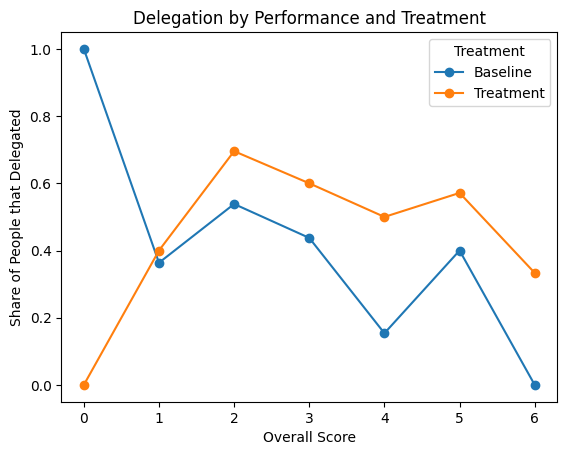

In [327]:
import pandas as pd
import matplotlib.pyplot as plt

# Group the data by 'overall_score' and 'treat', calculate the mean of 'delegation'
grouped = dg[(dg['pass_att2'] == 1)].groupby(['overall_score', 'treat'])['delegation'].mean().reset_index()

# Pivot the data to have 'overall_score' as index and 'treat' values as columns
pivot_df = grouped.pivot(index='overall_score', columns='treat', values='delegation')

# Rename columns for clarity in the legend
pivot_df.columns = pivot_df.columns.map({0: 'Baseline', 1: 'Treatment'})

# Sort the index to ensure the scores are in order
pivot_df = pivot_df.sort_index()

# Plot the data
pivot_df.plot(kind='line', marker='o')
plt.xlabel('Overall Score')
plt.ylabel('Share of People that Delegated')
plt.title('Delegation by Performance and Treatment')
plt.legend(title='Treatment')
plt.show()


In [63]:
print(np.corrcoef(dg[dg['treat']==1]['delegation'], dg[dg['treat']==1]['overall_score']))
print(np.corrcoef(dg[dg['treat']==0]['delegation'], dg[dg['treat']==0]['overall_score']))

[[ 1.         -0.02223123]
 [-0.02223123  1.        ]]
[[ 1.         -0.18938182]
 [-0.18938182  1.        ]]


In [170]:
dg['treat_x_overall_score'] = dg['treat']*dg['overall_score']

est = []

for d in [dg]:
    param_specs = [
        ['treat'],
        ['overall_score'],
        ['treat', 'overall_score', 'treat_x_overall_score'],
        ['nodel-del_good'],
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('delegation')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['delegation']
        X = sm.add_constant(reg[i])
        model = Probit(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
#stargazer.custom_columns(['All observations', 'cleaned punishment', 'cleaned att2'], [6, 6, 6])
stargazer.significant_digits(2)
#stargazer.covariate_order(['const', 'nodel_del_good', 'nodel_del_bad', 'participant.overall_score', 'wa_confidence', 'Age', 'female', 'switching_point'])
#stargazer.rename_covariates({'nodel_del_good': 'good (no del-del)', 'nodel_del_bad': 'bad (no del-del)', 'switching_point': 'risk aversion'})
stargazer.show_degrees_of_freedom(False)

stargazer

Optimization terminated successfully.
         Current function value: 0.678859
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.689475
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.669646
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.682388
         Iterations 4


In [172]:
grouped

,overall_score,treat,delegation
0,0,0,1.000000
1,0,1,0.000000
2,1,0,0.400000
3,1,1,0.400000
4,2,0,0.562500
5,2,1,0.692308
6,3,0,0.454545
7,3,1,0.611111
8,4,0,0.277778
9,4,1,0.526316


In [157]:
dg.delegation.value_counts()

1    82
0    79
Name: delegation, dtype: int64

# Punishment Beliefs

First, test whether they are significantly different between tretments because in no_punish they are hypothetical.

In [210]:
dg[['treat', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].groupby('treat').mean()

,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
treat,,,,
0,0.622500,0.922500,0.604375,0.979375
1,0.514815,0.892593,0.398148,0.870988


In [211]:
for i in ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']:
    print(ttest_ind(dg[dg['treat']==0][i], dg[dg['treat']==1][i]))

Ttest_indResult(statistic=1.0422729555747223, pvalue=0.29886731258673865)
Ttest_indResult(statistic=0.29523524501800974, pvalue=0.7681993484373584)
Ttest_indResult(statistic=2.096230718006871, pvalue=0.037645205285338545)
Ttest_indResult(statistic=1.1544175471831513, pvalue=0.2500611550852781)


In [212]:
#only the ones that passed the attention check on the first screen
dg[dg['pass_att2']==1][['treat', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].groupby('treat').mean()

,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
treat,,,,
0,0.533607,0.936066,0.516393,1.004098
1,0.500000,0.952857,0.347143,0.902143


In [213]:
#only the ones that didnt punish more for good outcomes regardless of delegation
dg[(dg['bad_good_del']>=0) | (dg['bad_good_nodel']>=0)][['treat', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].groupby('treat').mean()

,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
treat,,,,
0,0.498507,0.984328,0.466418,1.024627
1,0.400714,0.941429,0.275000,0.912143


## Test within subject

In [ ]:
ttest_rel(dg[dg['treat']==0]['belief_del_good'], dg[dg['treat']==0]['belief_nodel_good'])

TtestResult(statistic=0.3357656946058302, pvalue=0.7379376639807675, df=79)

# Delegation

## Tests for treatment differences

In [116]:
dg[['treat', 'delegation']].groupby(['treat']).mean()

,delegation
treat,
0,0.425000
1,0.592593


In [117]:
pd.crosstab(dg['treat'], dg['delegation'])

delegation,0,1
treat,,
0,46,34
1,33,48


In [118]:
#input contingency table, output chi2 test
stat, p, dof, expected = chi2_contingency(pd.crosstab(dg['treat'], dg['delegation']))
print(p)

0.04893158048933514


In [119]:
#input contingency table, output fisher exact test
fisher_exact(pd.crosstab(dg['treat'], dg['delegation']))

SignificanceResult(statistic=1.967914438502674, pvalue=0.040733639443774707)

In [122]:
for i in ['delegation']:
    print(ttest_ind(dg[dg['treat']==0][i], dg[dg['treat']==1][i]))

Ttest_indResult(statistic=-2.143920694630381, pvalue=0.0335592408790962)


## Order Effects of Delegation

In [123]:
pd.crosstab(dg['random_order_del'], dg['delegation'])

delegation,0,1
random_order_del,,
0,44,40
1,35,42


In [124]:
#by treatment order effect
for i in [0, 1]:
    print(pd.crosstab(dg[dg['treat']==i]['random_order_del'], dg[dg['treat']==i]['delegation']))

delegation         0   1
random_order_del        
0                 27  13
1                 19  21
delegation         0   1
random_order_del        
0                 17  27
1                 16  21


In [125]:
stat, p, dof, expected = chi2_contingency(pd.crosstab(dg['random_order_del'], dg['delegation']))
print(p)

0.4712878372402295


## Correlations with Performance

In [126]:
pointbiserialr(dg['delegation'], dg['wa_confidence'])

SignificanceResult(statistic=-0.08183131823613306, pvalue=0.3020887790213826)

In [127]:
dg[['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']].corr()

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,1.000000,-0.081831,-0.020329,-0.083574,-0.127819
wa_confidence,-0.081831,1.000000,0.792968,0.135807,0.619439
overconfidence,-0.020329,0.792968,1.000000,-0.495928,0.430408
participant.overall_score,-0.083574,0.135807,-0.495928,1.000000,0.182972
overconfidence_to_others,-0.127819,0.619439,0.430408,0.182972,1.000000


In [97]:
calculate_pvalues(dg[['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']]) 

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,0.0,0.2785,0.8144,0.2724,0.117
wa_confidence,0.2785,0.0,0.0,0.1813,0.0
overconfidence,0.8144,0.0,0.0,0.0,0.0
participant.overall_score,0.2724,0.1813,0.0,0.0,0.0368
overconfidence_to_others,0.117,0.0,0.0,0.0368,0.0


In [132]:
#punishment treatment only
dg[dg['treat']==0][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']].corr().round(3)

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,1.000,-0.092,0.036,-0.189,-0.015
wa_confidence,-0.092,1.000,0.801,0.075,0.603
overconfidence,0.036,0.801,1.000,-0.536,0.439
participant.overall_score,-0.189,0.075,-0.536,1.000,0.119
overconfidence_to_others,-0.015,0.603,0.439,0.119,1.000


In [133]:
calculate_pvalues(dg[dg['treat']==0][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']]) 

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,0.0,0.4165,0.7537,0.0925,0.8929
wa_confidence,0.4165,0.0,0.0,0.5078,0.0
overconfidence,0.7537,0.0,0.0,0.0,0.0
participant.overall_score,0.0925,0.5078,0.0,0.0,0.293
overconfidence_to_others,0.8929,0.0,0.0,0.293,0.0


In [134]:
#no punishment treatment only
dg[dg['treat']==1][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']].corr().round(3)

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,1.000,-0.094,-0.071,-0.022,-0.242
wa_confidence,-0.094,1.000,0.791,0.185,0.640
overconfidence,-0.071,0.791,1.000,-0.455,0.421
participant.overall_score,-0.022,0.185,-0.455,1.000,0.256
overconfidence_to_others,-0.242,0.640,0.421,0.256,1.000


In [135]:
calculate_pvalues(dg[dg['treat']==1][['delegation', 'wa_confidence', 'overconfidence', 'participant.overall_score', 'overconfidence_to_others']]) 

,delegation,wa_confidence,overconfidence,participant.overall_score,overconfidence_to_others
delegation,0.0,0.4044,0.5274,0.8438,0.0297
wa_confidence,0.4044,0.0,0.0,0.0989,0.0
overconfidence,0.5274,0.0,0.0,0.0,0.0001
participant.overall_score,0.8438,0.0989,0.0,0.0,0.021
overconfidence_to_others,0.0297,0.0,0.0001,0.021,0.0


## Correlations with Punishment Beliefs

In [153]:
dg[dg['treat']==0][['delegation', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].corr()

,delegation,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
delegation,1.000000,0.178352,-0.048260,0.276395,-0.042993
belief_del_good,0.178352,1.000000,0.240593,0.725543,0.238800
belief_del_bad,-0.048260,0.240593,1.000000,0.192279,0.651905
belief_nodel_good,0.276395,0.725543,0.192279,1.000000,0.212186
belief_nodel_bad,-0.042993,0.238800,0.651905,0.212186,1.000000


In [155]:
dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']].corr()

,delegation,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
delegation,1.000000,-0.062035,-0.234967,0.089290,-0.047449
belief_del_good,-0.062035,1.000000,0.498643,0.863618,0.369055
belief_del_bad,-0.234967,0.498643,1.000000,0.360667,0.699994
belief_nodel_good,0.089290,0.863618,0.360667,1.000000,0.374577
belief_nodel_bad,-0.047449,0.369055,0.699994,0.374577,1.000000


In [156]:
calculate_pvalues(dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad']])

,delegation,belief_del_good,belief_del_bad,belief_nodel_good,belief_nodel_bad
delegation,0.0,0.659,0.0903,0.5249,0.7358
belief_del_good,0.659,0.0,0.0001,0.0,0.0065
belief_del_bad,0.0903,0.0001,0.0,0.008,0.0
belief_nodel_good,0.5249,0.0,0.008,0.0,0.0057
belief_nodel_bad,0.7358,0.0065,0.0,0.0057,0.0


In [157]:
dg[['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']].corr()

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,1.000000,0.002093,-0.131983,0.142250,-0.055684
bad_good_del,0.002093,1.000000,0.525265,0.307457,-0.479183
bad_good_nodel,-0.131983,0.525265,1.000000,-0.346730,0.268703
nodel_del_good,0.142250,0.307457,-0.346730,1.000000,-0.046200
nodel_del_bad,-0.055684,-0.479183,0.268703,-0.046200,1.000000


In [158]:
dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']].corr()

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,1.000000,-0.186271,-0.118685,0.288735,0.236501
bad_good_del,-0.186271,1.000000,0.726684,-0.006442,-0.226973
bad_good_nodel,-0.118685,0.726684,1.000000,-0.183752,0.374844
nodel_del_good,0.288735,-0.006442,-0.183752,1.000000,0.352149
nodel_del_bad,0.236501,-0.226973,0.374844,0.352149,1.000000


In [6]:
dg[(dg['treat']==0) & (dg['pass_att2']>=0)][['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']].corr()

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,1.000000,-0.189070,-0.262704,0.129976,0.006014
bad_good_del,-0.189070,1.000000,0.616777,0.271784,-0.315086
bad_good_nodel,-0.262704,0.616777,1.000000,-0.329973,0.299391
nodel_del_good,0.129976,0.271784,-0.329973,1.000000,0.034643
nodel_del_bad,0.006014,-0.315086,0.299391,0.034643,1.000000


In [159]:
calculate_pvalues(dg[(dg['treat']==0) & (dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)][['delegation', 'bad_good_del', 'bad_good_nodel', 'nodel_del_good', 'nodel_del_bad']])

,delegation,bad_good_del,bad_good_nodel,nodel_del_good,nodel_del_bad
delegation,0.0,0.1817,0.3973,0.036,0.0882
bad_good_del,0.1817,0.0,0.0,0.9635,0.1022
bad_good_nodel,0.3973,0.0,0.0,0.1878,0.0057
nodel_del_good,0.036,0.9635,0.1878,0.0,0.0097
nodel_del_bad,0.0882,0.1022,0.0057,0.0097,0.0


In [62]:
## Hypothetical delegation
pd.crosstab(dg['delegation_hypo'], dg['delegation'])

delegation,0,1
delegation_hypo,,
0.0,28,12
1.0,5,36


# Regressions

## Punishment Treatment only

In [44]:
est = []

for d in [dg[dg['treat']==0], dg[(dg['treat']==0) & ((dg['bad_good_del']>=0) | (dg['bad_good_nodel']>=0))], dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
#for d in [dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
    param_specs = [
        ['nodel_del_good', 'nodel_del_bad'],
        ['nodel_del_good', 'nodel_del_bad'],
        ['nodel_del_good', 'nodel_del_bad', 'participant.overall_score'],
        ['nodel_del_good', 'nodel_del_bad', 'participant.overall_score', 'switching_point', 'Age', 'female'],
        ['nodel_del_good', 'nodel_del_bad', 'wa_confidence'],
        ['nodel_del_good', 'nodel_del_bad', 'wa_confidence', 'switching_point', 'Age', 'female'],
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('delegation')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['delegation']
        X = sm.add_constant(reg[i])
        model = Probit(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'cleaned punishment', 'cleaned att2'], [6, 6, 6])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'nodel_del_good', 'nodel_del_bad', 'participant.overall_score', 'wa_confidence', 'Age', 'female', 'switching_point'])
stargazer.rename_covariates({'nodel_del_good': 'good (no del-del)', 'nodel_del_bad': 'bad (no del-del)', 'switching_point': 'risk aversion'})
stargazer.show_degrees_of_freedom(False)

stargazer

Optimization terminated successfully.
         Current function value: 0.668252
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.668252
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664751
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.600182
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.664486
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.581197
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.558091
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.558091
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.539365
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.497946
  

In [47]:
est = []

for d in [dg[dg['treat']==0], dg[(dg['treat']==0) & ((dg['bad_good_del']>=0) | (dg['bad_good_nodel']>=0))], dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
#for d in [dg[(dg['treat']==0) & (dg['pass_att2']==1)]]:
    param_specs = [
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'participant.overall_score'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'participant.overall_score', 'switching_point', 'Age', 'female'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'wa_confidence'],
        ['belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'wa_confidence', 'switching_point', 'Age', 'female'],
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('delegation')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['delegation']
        X = sm.add_constant(reg[i])
        model = Probit(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'cleaned punishment', 'cleaned att2'], [5, 5, 5])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'belief_del_good', 'belief_del_bad', 'belief_nodel_good', 'belief_nodel_bad', 'participant.overall_score', 'wa_confidence', 'Age', 'female', 'switching_point'])
stargazer.rename_covariates({'nodel_del_good': 'good (no del-del)', 'nodel_del_bad': 'bad (no del-del)', 'switching_point': 'risk aversion'})
stargazer.show_degrees_of_freedom(False)

stargazer

Optimization terminated successfully.
         Current function value: 0.622795
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.620544
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.513120
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.620926
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.475983
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.506425
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.487700
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.378686
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.505882
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.391881
  

## Treatment comparison

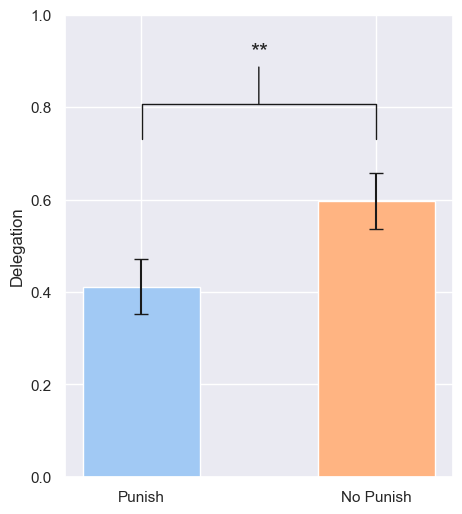

In [38]:
sns.set_theme()
sns.set_palette("pastel")

plt.figure(figsize=(5, 6))

a=0.2 
t_0 = dg[(dg['treat']==0)][['delegation']].agg(['mean', 'sem']).T
t_1 = dg[(dg['treat']==1)][['delegation']].agg(['mean', 'sem']).T

#plt.errorbar([i-a for i in [1, 2, 3, 4]], t_all['mean'], yerr=t_all['sem'], fmt='o', capsize=5, label='all', markerfacecolor='grey')
plt.bar([1], t_0['mean'], yerr=t_0['sem'], capsize=5, width=0.05)
plt.bar([1.1], t_1['mean'], yerr=t_1['sem'], capsize=5, width=0.05)

fs = 11.0
plt.annotate('**', xy=(0.5, 0.8), xytext=(0.5, 0.9), xycoords='axes fraction', 
            fontsize=fs*1.5, ha='center', va='bottom',
            arrowprops=dict(arrowstyle='-[, widthB=5.1, lengthB=1.5', lw=1.0, color='k'))

plt.ylabel('Delegation')
plt.ylim(0, 1)
plt.xticks([1, 1.1], ['Punish', 'No Punish'])
#plt.legend(fontsize='small', loc='upper left')
#plt.savefig('del_treat.png', dpi=300, bbox_inches='tight')
plt.show()



In [45]:
est = []

for d in [dg, dg[(dg['bad_good_del']>=0) & (dg['bad_good_nodel']>=0)], dg[dg['pass_att2']==1]]:
    param_specs = [
        ['treat'],
        ['treat', 'nodel_del_good', 'nodel_del_bad'],
        ['treat', 'nodel_del_good', 'nodel_del_bad', 'nodel_del_good_x_treat', 'nodel_del_bad_x_treat'],
        ['treat', 'wa_confidence'],
        ['treat', 'overconfidence'],
        ['treat', 'wa_difficulty'],
        ['treat', 'overconfidence_to_others'],
        ['treat', 'participant.overall_score'],
        ['treat', 'participant.overall_score', 'switching_point', 'nodel_del_good', 'nodel_del_bad', 'Age', 'female']
    ]

    
    for i in param_specs:
        l = i.copy()
        l.append('delegation')

        reg = d[l].copy()
        reg = reg.dropna()
        Y = reg['delegation']
        X = sm.add_constant(reg[i])
        model = Probit(Y.astype(float),X.astype(float)).fit()
        est.append(model)
stargazer = Stargazer(est)
stargazer.custom_columns(['All observations', 'cleaned punishment', 'cleaned att2'], [9, 9, 9])
stargazer.significant_digits(2)
stargazer.covariate_order(['const', 'treat', 'nodel_del_good', 'nodel_del_bad', 'nodel_del_good_x_treat', 'nodel_del_bad_x_treat', 'Age', 'female', 'switching_point', 'wa_confidence', 'overconfidence', 'wa_difficulty', 'overconfidence_to_others', 'participant.overall_score'])
stargazer.rename_covariates({'nodel_del_good': 'good (no del-del)', 'nodel_del_bad': 'bad (no del-del)', 'switching_point': 'risk aversion'})
stargazer.show_degrees_of_freedom(False)

stargazer

Optimization terminated successfully.
         Current function value: 0.672688
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.647357
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.646967
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.672666
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.672659
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671745
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.671737
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.672682
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.637142
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.653719
  

wa_confidence makes most sense, but if matters if I am better than others. I must not be good, I must just be better than others and I will do it myself instead of delegating to an unrelated algorithm

check with all the prolific metadata

analyze delegation_hypo

graphs instead of correlations maybe to make it prettier?